#  Классификация изображений с помощью сверточных нейронных сетей

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.html#convolution-layers
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://kozodoi.me/blog/20210308/compute-image-stats
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.matshow.html

## Задачи для совместного разбора

In [1]:
# Используемые библиотеки
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import zipfile
from sklearn.model_selection import train_test_split
from collections import Counter
import glob
import time
import random
import seaborn as sns
from sklearn.metrics import accuracy_score

1\. Рассмотрите основные возможности по созданию датасетов из `torchvision` и примеры работы основных слоев для создания сверточных нейронных сетей для анализа изображений.

In [2]:
batch_size = 32
num_workers = 2

In [3]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # для grayscale
])

transform_color = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # для RGB
])

In [4]:
# MNIST - рукописные цифры
train_mnist = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_mnist = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [5]:
# CIFAR-10 - цветные изображения 10 классов
train_cifar10 = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_color
)
test_cifar10 = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_color
)

In [6]:
# CIFAR-100 - цветные изображения 100 классов
train_cifar100 = torchvision.datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform_color
)

In [7]:
# FashionMNIST - изображения одежды
train_fashion = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

In [8]:
# DataLoader для батчевой обработки
train_loader_mnist = torch.utils.data.DataLoader(
    train_mnist,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

test_loader_mnist = torch.utils.data.DataLoader(
    test_mnist,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

train_loader_cifar10 = torch.utils.data.DataLoader(
    train_cifar10,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

In [9]:
def imshow(img, title=None):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [10]:
dataiter = iter(train_loader_mnist)
images, labels = next(dataiter)

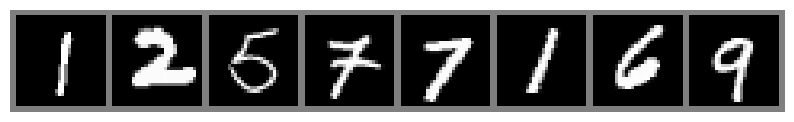

Labels: [1 2 5 7 7 1 6 9]


In [11]:
imshow(torchvision.utils.make_grid(images[:8]))
print('Labels:', labels[:8].numpy())

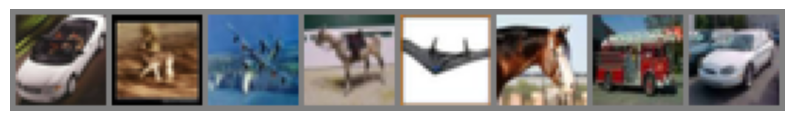

In [12]:
dataiter_cifar = iter(train_loader_cifar10)
images_cifar, labels_cifar = next(dataiter_cifar)
imshow(torchvision.utils.make_grid(images_cifar[:8]))

In [13]:
class SimpleCNN(nn.Module):
    """Простая сверточная нейронная сеть для MNIST"""

    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Сверточные слои
        self.conv1 = nn.Conv2d(
            in_channels=1,      # входные каналы (grayscale)
            out_channels=32,    # количество фильтров
            kernel_size=3,      # размер ядра
            padding=1          # padding для сохранения размера
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Pooling слои
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        # Полносвязные слои
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # после двух poolings 28x28 -> 14x14 -> 7x7
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Первый сверточный блок
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)

        # Второй сверточный блок
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)

        x = x.view(-1, 64 * 7 * 7)

        # Полносвязные слои
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)

        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


2\. Реализуйте типовую архитектуру CNN для классификации изображений.

In [14]:
batch_size = 128
learning_rate = 0.001
num_epochs = 10
num_classes = 10

In [15]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [16]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

In [17]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [18]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [19]:
class CNN(nn.Module):
    """
    Conv -> BatchNorm -> ReLU -> Pooling -> Dropout
    """

    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        # Первый сверточный блок
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        # Второй сверточный блок
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        # Третий сверточный блок
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        # Инициализация весов
        self._initialize_weights()

    def _initialize_weights(self):
        """Инициализация весов сети"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Сверточные блоки
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        # Вытягивание в вектор
        x = x.view(x.size(0), -1)

        # Классификатор
        x = self.classifier(x)

        return x

In [20]:
model = CNN(num_classes=num_classes); model

CNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace

In [21]:
def count_parameters(model): # Подсчёт параметров модели
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [22]:
total_params = count_parameters(model); total_params

3380298

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [24]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc="Training")
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs, targets = inputs, targets

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        pbar.set_postfix({
            'Loss': f'{running_loss/(batch_idx+1):.3f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [25]:
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation")
        for batch_idx, (inputs, targets) in enumerate(pbar):
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            pbar.set_postfix({
                'Loss': f'{running_loss/(batch_idx+1):.3f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [26]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print("Начало обучения...")
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)

    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, 'cpu')

    # Валидация
    val_loss, val_acc = validate_epoch(model, test_loader, criterion, 'cpu')

    # Обновление scheduler
    scheduler.step()

    # Сохранение метрик
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

Начало обучения...

Epoch 1/10
--------------------------------------------------


Validation: 100%|███████████████████████████████████████████████| 79/79 [00:02<00:00, 27.24it/s, Loss=1.138, Acc=59.56%]


Train Loss: 1.5115, Train Acc: 44.34%
Val Loss: 1.1383, Val Acc: 59.56%

Epoch 2/10
--------------------------------------------------


Validation: 100%|███████████████████████████████████████████████| 79/79 [00:02<00:00, 29.14it/s, Loss=0.896, Acc=67.62%]


Train Loss: 1.1260, Train Acc: 59.67%
Val Loss: 0.8960, Val Acc: 67.62%

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.6747, Train Acc: 77.00%
Val Loss: 0.5348, Val Acc: 81.72%

Epoch 9/10
--------------------------------------------------


Validation: 100%|███████████████████████████████████████████████| 79/79 [00:03<00:00, 23.48it/s, Loss=0.560, Acc=80.42%]


Train Loss: 0.6446, Train Acc: 77.94%
Val Loss: 0.5601, Val Acc: 80.42%

Epoch 10/10
--------------------------------------------------


Validation: 100%|███████████████████████████████████████████████| 79/79 [00:02<00:00, 27.83it/s, Loss=0.480, Acc=83.49%]

Train Loss: 0.6185, Train Acc: 78.90%
Val Loss: 0.4801, Val Acc: 83.49%


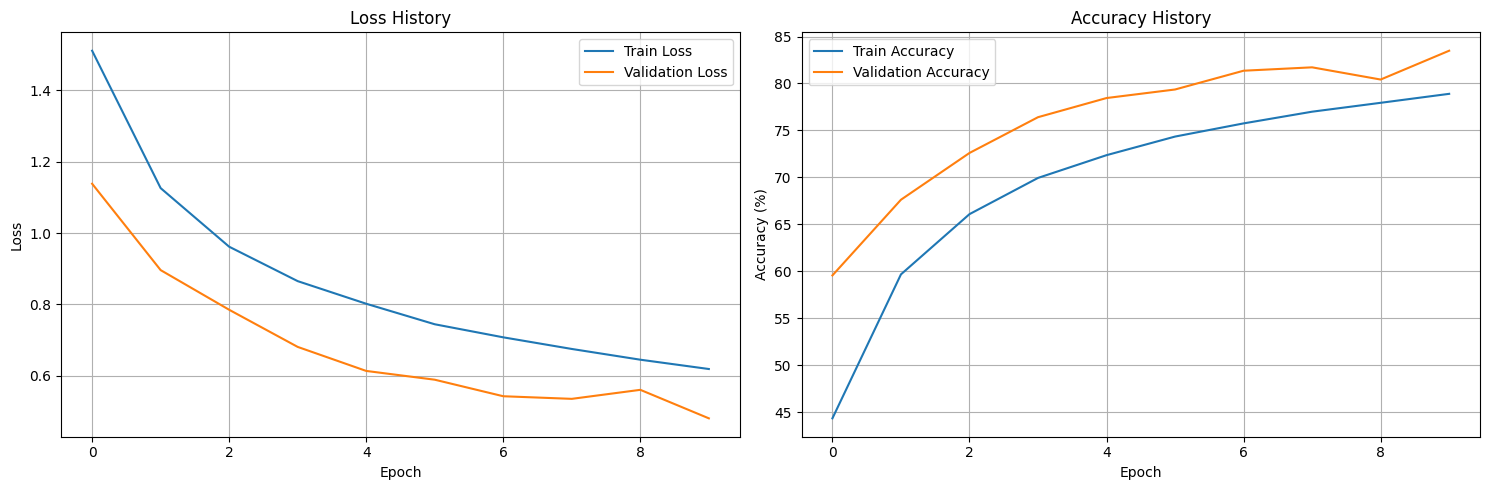

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('Loss History')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('Accuracy History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [28]:
device = 'cpu'

In [29]:
model.eval()
class_correct = list(0. for i in range(len(classes)))
class_total = list(0. for i in range(len(classes)))

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to('cpu'), labels.to('cpu')
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()

        for i in range(labels.size(0)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

print("\nТочность по классам:")
for i in range(len(classes)):
    if class_total[i] > 0:
        print(f'{classes[i]:10s}: {100 * class_correct[i] / class_total[i]:.2f}%')


Точность по классам:
plane     : 84.20%
car       : 94.10%
bird      : 81.40%
cat       : 63.40%
deer      : 91.30%
dog       : 73.20%
frog      : 87.40%
horse     : 80.30%
ship      : 89.80%
truck     : 89.80%


In [30]:
# Сохранение модели
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accuracies,
    'val_accuracies': val_accuracies
}, 'typical_cnn_cifar10.pth')


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Используя преобразования `torchvision`, приведите картинки к размеру 300х300 и нормализуйте значения интенсивности пикселей (рассчитайте статистику для нормализации отдельно). Выведите на экран количество картинок в датасете,  размер одной картинки, количество уникальных классов. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%.

- [ ] Проверено на семинаре

=== СОЗДАНИЕ ДАТАСЕТА CAT BREEDS ===

Директория ./cat_breeds_data уже существует

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество изображений: 4000
Количество уникальных классов: 4
Уникальные классы: ['American Shorthair', 'Persian', 'Russian Blue', 'Tiger']
Размер первого изображения: (300, 409)

=== РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ ===
  Russian Blue: 1000 изображений
  Tiger: 1000 изображений
  American Shorthair: 1000 изображений
  Persian: 1000 изображений

=== РАСЧЕТ СТАТИСТИКИ ДЛЯ НОРМАЛИЗАЦИИ ===
Вычисляем статистику для нормализации...
Среднее значение по каналам (RGB): ['0.5000', '0.4514', '0.4066']
Стандартное отклонение по каналам (RGB): ['0.2324', '0.2273', '0.2228']

=== РАЗДЕЛЕНИЕ ДАННЫХ ===
Обучающая выборка: 3200 изображений (80.0%)
Тестовая выборка: 800 изображений (20.0%)

=== СОЗДАННЫЕ ДАТАСЕТЫ ===
Размер обучающего датасета: 3200
Размер тестового датасета: 800
Маппинг классов: {'American Shorthair': 0, 'Persian': 1, 'Russian Blue': 2, 'Tiger': 3}

=== ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ =

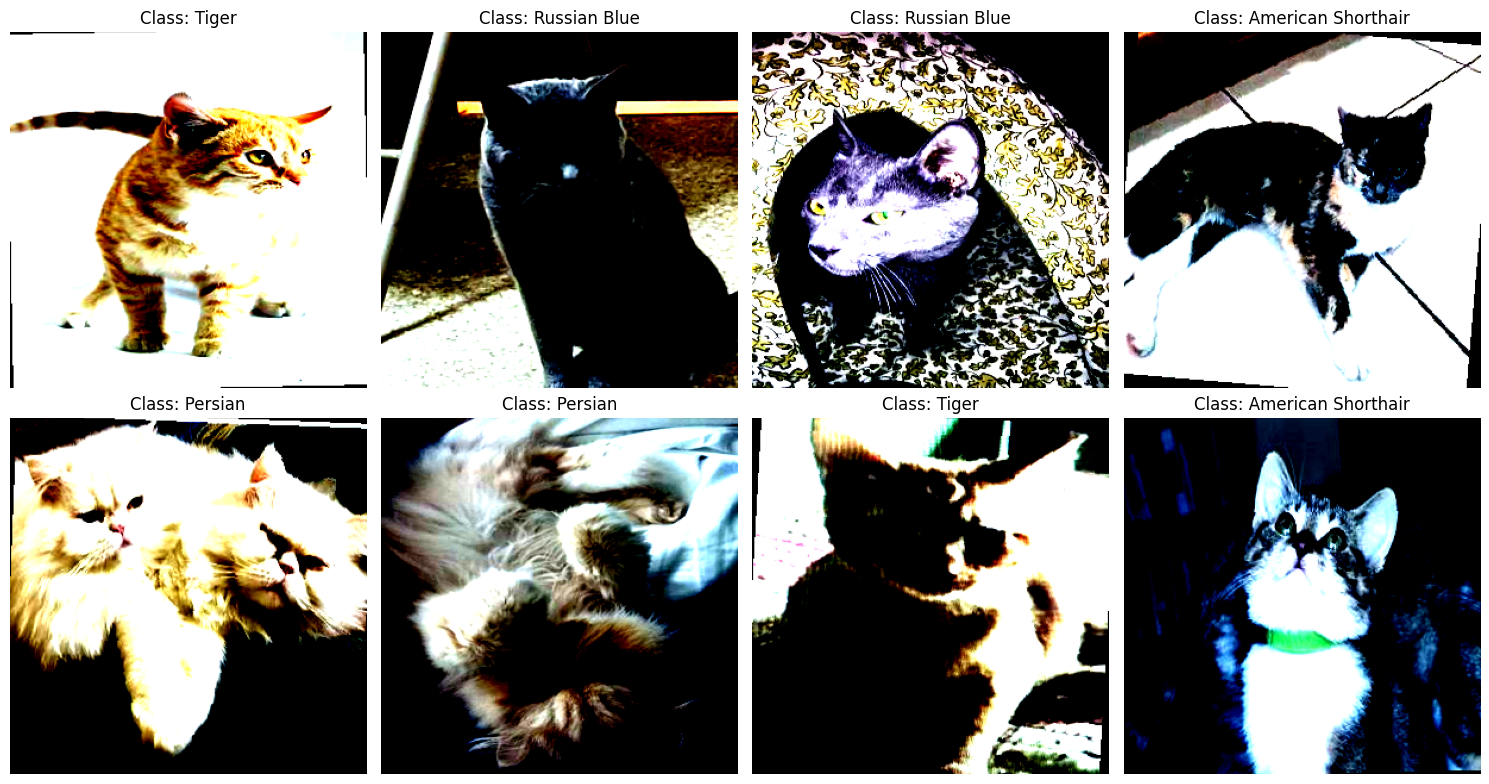


=== DATALOADER ===
Размер батча: 32
Количество батчей в train: 100
Количество батчей в test: 25

 ДАТАСЕТ CAT BREEDS УСПЕШНО СОЗДАН!
 Итоговая статистика:
   - Всего изображений: 4000
   - Обучающая выборка: 3200
   - Тестовая выборка: 800
   - Количество классов: 4
   - Классы: ['American Shorthair', 'Persian', 'Russian Blue', 'Tiger']


In [31]:
import zipfile
import os
from PIL import Image
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

class CatBreedsDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.classes = sorted(set(labels))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.idx_to_class = {idx: cls_name for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label_idx = self.class_to_idx[label]
        return image, label_idx

    def get_class_mapping(self):
        return self.class_to_idx, self.idx_to_class

def extract_zip(zip_path='cat_breeds_4.zip', extract_to='./cat_breeds_data'):
    """Распаковывает архив с датасетом"""
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Архив {zip_path} не найден!")

    print("Распаковка архива...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Архив распакован в {extract_to}")
    return True

def find_images_and_labels(data_dir):
    """Находит все изображения и соответствующие метки в директории"""
    image_paths = []
    labels = []

    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                image_paths.append(os.path.join(root, file))
                label = os.path.basename(root)
                labels.append(label)

    return image_paths, labels

def calculate_dataset_statistics(image_paths, target_size=(300, 300)):
    """Вычисляет среднее и стандартное отклонение для нормализации"""
    print("Вычисляем статистику для нормализации...")

    # Временные преобразования только для изменения размера
    temp_transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor()
    ])

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_pixels = 0

    for i, image_path in enumerate(image_paths):
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = temp_transform(image)

            # Вычисляем статистику по батчу
            mean += image_tensor.mean(dim=(1, 2))
            std += image_tensor.std(dim=(1, 2))

        except Exception as e:
            print(f"Ошибка при обработке {image_path}: {e}")
            continue

    mean /= len(image_paths)
    std /= len(image_paths)

    return mean.tolist(), std.tolist()

def visualize_samples(dataset, num_samples=8):
    """Визуализирует примеры из датасета"""
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()

    for i in range(num_samples):
        image, label_idx = dataset[i]

        # Денормализуем изображение для отображения
        image_np = image.numpy().transpose((1, 2, 0))

        # Обрезаем значения для корректного отображения
        image_np = np.clip(image_np, 0, 1)

        axes[i].imshow(image_np)
        axes[i].set_title(f"Class: {dataset.idx_to_class[label_idx]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def create_catbreeds_datasets():
    """Основная функция для создания датасета CatBreeds"""

    # Параметры
    zip_path = 'cat_breeds_4.zip'
    data_dir = './cat_breeds_data'
    target_size = (300, 300)
    test_size = 0.2
    random_state = 42

    print("=== СОЗДАНИЕ ДАТАСЕТА CAT BREEDS ===\n")

    # 1. Распаковка архива
    if not os.path.exists(data_dir):
        extract_zip(zip_path, data_dir)
    else:
        print(f"Директория {data_dir} уже существует")

    # 2. Поиск изображений и меток
    image_paths, labels = find_images_and_labels(data_dir)

    if len(image_paths) == 0:
        raise ValueError("Не найдено изображений в датасете!")

    # 3. Вывод основной информации
    print(f"\n=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
    print(f"Общее количество изображений: {len(image_paths)}")
    print(f"Количество уникальных классов: {len(set(labels))}")
    print(f"Уникальные классы: {sorted(set(labels))}")

    # Проверка размера первого изображения
    sample_image = Image.open(image_paths[0])
    print(f"Размер первого изображения: {sample_image.size}")

    # 4. Распределение по классам
    print(f"\n=== РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ ===")
    class_distribution = Counter(labels)
    for breed, count in class_distribution.items():
        print(f"  {breed}: {count} изображений")

    # 5. Расчет статистики для нормализации
    print(f"\n=== РАСЧЕТ СТАТИСТИКИ ДЛЯ НОРМАЛИЗАЦИИ ===")
    mean, std = calculate_dataset_statistics(image_paths, target_size)
    print(f"Среднее значение по каналам (RGB): {[f'{x:.4f}' for x in mean]}")
    print(f"Стандартное отклонение по каналам (RGB): {[f'{x:.4f}' for x in std]}")

    # 6. Разделение на обучающую и тестовую выборки
    print(f"\n=== РАЗДЕЛЕНИЕ ДАННЫХ ===")
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        image_paths,
        labels,
        test_size=test_size,
        random_state=random_state,
        stratify=labels  # Стратифицированное разделение для сохранения пропорций классов
    )

    print(f"Обучающая выборка: {len(train_paths)} изображений ({len(train_paths)/len(image_paths)*100:.1f}%)")
    print(f"Тестовая выборка: {len(test_paths)} изображений ({len(test_paths)/len(image_paths)*100:.1f}%)")

    # 7. Определение преобразований
    train_transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(degrees=5),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    test_transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    # 8. Создание датасетов
    train_dataset = CatBreedsDataset(train_paths, train_labels, train_transform)
    test_dataset = CatBreedsDataset(test_paths, test_labels, test_transform)

    class_to_idx, idx_to_class = train_dataset.get_class_mapping()

    print(f"\n=== СОЗДАННЫЕ ДАТАСЕТЫ ===")
    print(f"Размер обучающего датасета: {len(train_dataset)}")
    print(f"Размер тестового датасета: {len(test_dataset)}")
    print(f"Маппинг классов: {class_to_idx}")

    # 9. Визуализация примеров
    print(f"\n=== ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ===")
    visualize_samples(train_dataset)

    # 10. Создание DataLoader'ов
    batch_size = 32
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    print(f"\n=== DATALOADER ===")
    print(f"Размер батча: {batch_size}")
    print(f"Количество батчей в train: {len(train_loader)}")
    print(f"Количество батчей в test: {len(test_loader)}")

    return train_dataset, test_dataset, train_loader, test_loader, class_to_idx, idx_to_class

# Запуск создания датасета
if __name__ == "__main__":
    try:
        train_dataset, test_dataset, train_loader, test_loader, class_to_idx, idx_to_class = create_catbreeds_datasets()

        print("\n" + "="*50)
        print(" ДАТАСЕТ CAT BREEDS УСПЕШНО СОЗДАН!")
        print("="*50)
        print(f" Итоговая статистика:")
        print(f"   - Всего изображений: {len(train_dataset) + len(test_dataset)}")
        print(f"   - Обучающая выборка: {len(train_dataset)}")
        print(f"   - Тестовая выборка: {len(test_dataset)}")
        print(f"   - Количество классов: {len(class_to_idx)}")
        print(f"   - Классы: {list(class_to_idx.keys())}")

    except Exception as e:
        print(f" Ошибка при создании датасета: {e}")

<p class="task" id="2"></p>

2\. Решите задачу классификации на основе датасета из предыдущего задания, не используя сверточные слои. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. Выведите на экран количество параметров модели.   

- [ ] Проверено на семинаре

In [32]:
class CatBreedClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CatBreedClassifier, self).__init__()

        # Размер после выравнивания: 3 * 300 * 300 = 270000
        self.flatten = nn.Flatten()

        # Полносвязная архитектура
        self.classifier = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [33]:
num_epochs = 100

КЛАССИФИКАЦИЯ ПОРОД КОШЕК БЕЗ СВЕРТОЧНЫХ СЛОЕВ
=== СОЗДАНИЕ ДАТАСЕТА CAT BREEDS ===

Директория ./cat_breeds_data уже существует

=== ОСНОВНАЯ ИНФОРМАЦИЯ ===
Общее количество изображений: 4000
Количество уникальных классов: 4
Уникальные классы: ['American Shorthair', 'Persian', 'Russian Blue', 'Tiger']
Размер первого изображения: (300, 409)

=== РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ ===
  Russian Blue: 1000 изображений
  Tiger: 1000 изображений
  American Shorthair: 1000 изображений
  Persian: 1000 изображений

=== РАСЧЕТ СТАТИСТИКИ ДЛЯ НОРМАЛИЗАЦИИ ===
Вычисляем статистику для нормализации...
Среднее значение по каналам (RGB): ['0.5000', '0.4514', '0.4066']
Стандартное отклонение по каналам (RGB): ['0.2324', '0.2273', '0.2228']

=== РАЗДЕЛЕНИЕ ДАННЫХ ===
Обучающая выборка: 3200 изображений (80.0%)
Тестовая выборка: 800 изображений (20.0%)

=== СОЗДАННЫЕ ДАТАСЕТЫ ===
Размер обучающего датасета: 3200
Размер тестового датасета: 800
Маппинг классов: {'American Shorthair': 0, 'Persian': 1, 'Russian Blu

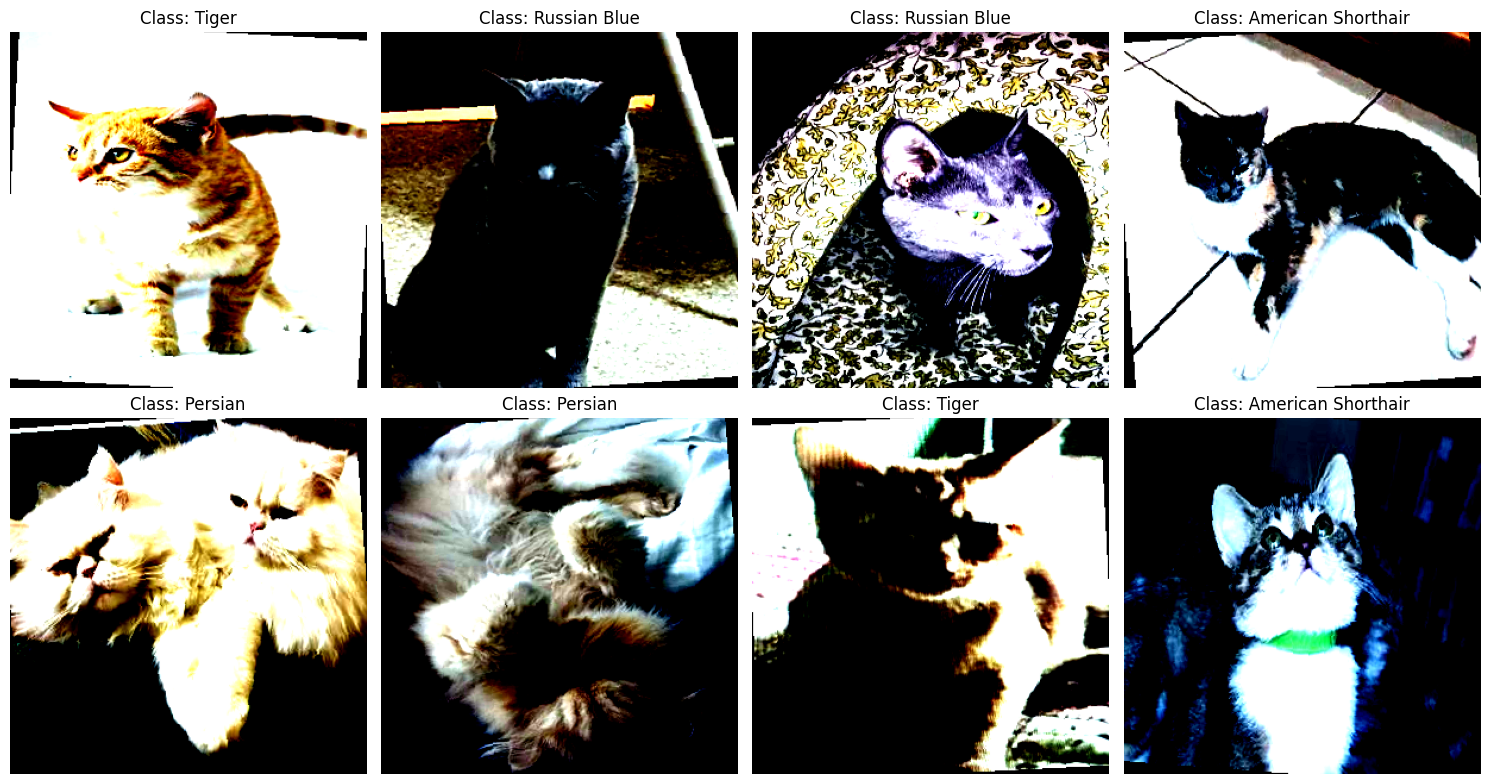


=== DATALOADER ===
Размер батча: 32
Количество батчей в train: 100
Количество батчей в test: 25

ПАРАМЕТРЫ МОДЕЛИ:
Размер входного вектора: 270000
Количество классов: 4
Классы: ['American Shorthair', 'Persian', 'Russian Blue', 'Tiger']

АРХИТЕКТУРА МОДЕЛИ:
CatBreedClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=270000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace

Epoch 1/100: 100%|███████████████████████████████████████████| 100/100 [00:03<00:00, 30.82it/s, Loss=1.2551, Acc=31.97%]


Epoch [1/100] - Loss: 1.3762, Train Acc: 31.97%, Test Acc: 37.50%


Epoch 2/100: 100%|███████████████████████████████████████████| 100/100 [00:02<00:00, 36.30it/s, Loss=1.3063, Acc=35.06%]


Epoch [2/100] - Loss: 1.3297, Train Acc: 35.06%, Test Acc: 36.50%


...

Epoch [98/100] - Loss: 1.2833, Train Acc: 40.12%, Test Acc: 40.62%


Epoch 99/100: 100%|██████████████████████████████████████████| 100/100 [00:03<00:00, 30.19it/s, Loss=1.3754, Acc=39.12%]


Epoch [99/100] - Loss: 1.2798, Train Acc: 39.12%, Test Acc: 40.12%


Epoch 100/100: 100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 35.55it/s, Loss=1.3683, Acc=40.91%]


Epoch [100/100] - Loss: 1.2784, Train Acc: 40.91%, Test Acc: 40.25%

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:
Accuracy на обучающем множестве: 43.78%
Accuracy на тестовом множестве: 40.25%


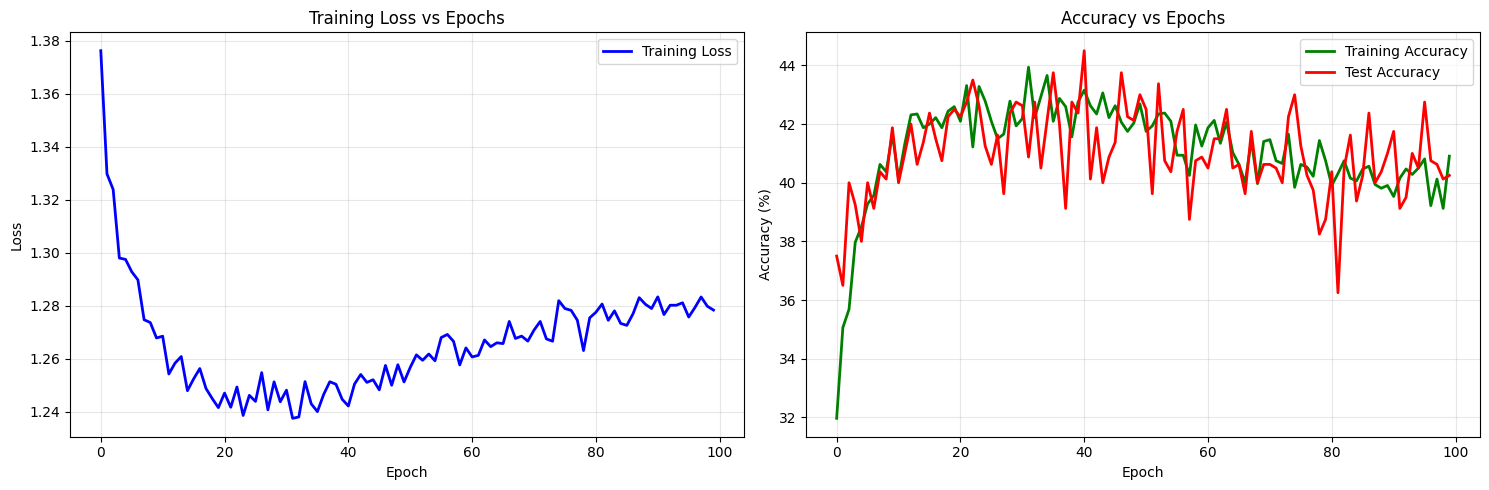


АНАЛИЗ РЕЗУЛЬТАТОВ:
Лучшая accuracy на обучении: 43.94%
Лучшая accuracy на тесте: 44.50%
Финальное значение потерь: 1.2784

Модель сохранена как 'cat_breed_classifier.pth'


In [34]:
def train_model(model, train_loader, test_loader, num_epochs=100, learning_rate=0.001):
    """Обучает модель и возвращает метрики"""

    # Устройство (CPU/GPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используемое устройство: {device}")

    model = model.to(device)

    # Функция потерь и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # Списки для хранения метрик
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    # Обучение
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # Прогресс-бар для обучающей выборки
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Статистика
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            # Обновление прогресс-бара
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct_train/total_train:.2f}%'
            })

        # Средняя потеря за эпоху
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # Accuracy на обучающей выборке
        train_accuracy = 100. * correct_train / total_train
        train_accuracies.append(train_accuracy)

        # Accuracy на тестовой выборке
        test_accuracy = evaluate_model(model, test_loader, device)
        test_accuracies.append(test_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] - '
              f'Loss: {epoch_loss:.4f}, '
              f'Train Acc: {train_accuracy:.2f}%, '
              f'Test Acc: {test_accuracy:.2f}%')

    return train_losses, train_accuracies, test_accuracies

def evaluate_model(model, test_loader, device):
    """Оценивает модель на тестовой выборке"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100. * correct / total

def plot_training_metrics(train_losses, train_accuracies, test_accuracies):
    """Строит графики обучения"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # График потерь
    ax1.plot(train_losses, 'b-', linewidth=2, label='Training Loss')
    ax1.set_title('Training Loss vs Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # График accuracy
    ax2.plot(train_accuracies, 'g-', linewidth=2, label='Training Accuracy')
    ax2.plot(test_accuracies, 'r-', linewidth=2, label='Test Accuracy')
    ax2.set_title('Accuracy vs Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def count_parameters(model):
    """Считает количество параметров модели"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def main_classification():
    """Основная функция для классификации"""

    print("=" * 60)
    print("КЛАССИФИКАЦИЯ ПОРОД КОШЕК БЕЗ СВЕРТОЧНЫХ СЛОЕВ")
    print("=" * 60)

    train_dataset, test_dataset, train_loader, test_loader, class_to_idx, idx_to_class = create_catbreeds_datasets()

    if train_dataset is None:
        print("Не удалось создать датасет. Завершение работы.")
        return

    # Параметры модели
    input_size = 3 * 300 * 300  # RGB * width * height
    num_classes = len(class_to_idx)

    print(f"\nПАРАМЕТРЫ МОДЕЛИ:")
    print(f"Размер входного вектора: {input_size}")
    print(f"Количество классов: {num_classes}")
    print(f"Классы: {list(class_to_idx.keys())}")

    model = CatBreedClassifier(input_size, num_classes)

    print(f"\nАРХИТЕКТУРА МОДЕЛИ:")
    print(model)
    total_params = count_parameters(model)
    print(f"\nКОЛИЧЕСТВО ПАРАМЕТРОВ МОДЕЛИ: {total_params:,}")
    print(f"\nНАЧАЛО ОБУЧЕНИЯ:")
    train_losses, train_accuracies, test_accuracies = train_model(
        model, train_loader, test_loader, num_epochs=100
    )

    # Финальная оценка
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    final_train_accuracy = evaluate_model(model, train_loader, device)
    final_test_accuracy = evaluate_model(model, test_loader, device)

    print(f"\nФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
    print(f"Accuracy на обучающем множестве: {final_train_accuracy:.2f}%")
    print(f"Accuracy на тестовом множестве: {final_test_accuracy:.2f}%")
    plot_training_metrics(train_losses, train_accuracies, test_accuracies)

    # Анализ результатов
    print(f"\nАНАЛИЗ РЕЗУЛЬТАТОВ:")
    best_train_acc = max(train_accuracies)
    best_test_acc = max(test_accuracies)
    final_loss = train_losses[-1]

    print(f"Лучшая accuracy на обучении: {best_train_acc:.2f}%")
    print(f"Лучшая accuracy на тесте: {best_test_acc:.2f}%")
    print(f"Финальное значение потерь: {final_loss:.4f}")

    torch.save(model.state_dict(), 'cat_breed_classifier.pth')
    print(f"\nМодель сохранена как 'cat_breed_classifier.pth'")

    return model, train_losses, train_accuracies, test_accuracies


def predict_single_image(model, image_path, transform, class_names, device):
    """Предсказывает класс для одного изображения"""
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Предсказание
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_value = confidence.item()

    return predicted_class, confidence_value

# Запуск классификации
if __name__ == "__main__":
    model, train_losses, train_accuracies, test_accuracies = main_classification()

In [35]:
device = 'cuda'

<p class="task" id="3"></p>

3\. Напишите функцию, которая выбирает несколько изображений из переданного набора данных и выводит их на экран в виде сетки с указанием над ними названия правильного класса и класса, предсказанного моделью. Воспользовавшись данной функцией, выведите прогнозы итоговой модели из предыдущей задачи по 6 случайным картинкам.

```
def show_examples(model, dataset, k=6):
    pass
```

- [ ] Проверено на семинаре

In [36]:
def denormalize_image(tensor_image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = tensor_image.clone()
    image = image * std + mean
    image = torch.clamp(image, 0, 1)
    image_np = image.numpy().transpose(1, 2, 0)
    return image_np

In [37]:
def show_examples(model, dataset, k=6, device='cpu', show_confidence=True):
    model.eval()
    indices = random.sample(range(len(dataset)), k)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.ravel()
    class_to_idx, idx_to_class = dataset.get_class_mapping()
    with torch.no_grad():
        for i, idx in enumerate(indices):
            if i >= k:
                break

            image, true_label_idx = dataset[idx]
            image_tensor = image.unsqueeze(0).to(device)
            output = model(image_tensor)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

            true_label = idx_to_class[true_label_idx]
            predicted_label = idx_to_class[predicted_idx.item()]
            conf_value = confidence.item()

            image_np = denormalize_image(image)

            axes[i].imshow(image_np)

            color = 'green' if true_label == predicted_label else 'red'
            if show_confidence:
                title = f'True: {true_label}\nPred: {predicted_label}\nConf: {conf_value:.3f}'
            else:
                title = f'True: {true_label}\nPred: {predicted_label}'

            axes[i].set_title(title, color=color, fontsize=11, fontweight='bold')
            axes[i].axis('off')

            for spine in axes[i].spines.values():
                spine.set_color(color)
                spine.set_linewidth(3)

    plt.tight_layout()
    plt.show()

    return indices

In [38]:
def demonstrate_model_predictions():
    print("\n" + "="*60)
    print("ПРИМЕРЫ С УКАЗАНИЕМ УВЕРЕННОСТИ")
    print("="*60)
    print("ОБУЧАЮЩИЙ ДАТАСЕТ")
    print("\n" + "")
    show_examples(model, train_dataset, k=6, device=device, show_confidence=True)
    print("ТЕСТОВЫЙ ДАТАСЕТ")
    show_examples(model, test_dataset, k=6, device=device, show_confidence=True)


ПРИМЕРЫ С УКАЗАНИЕМ УВЕРЕННОСТИ
ОБУЧАЮЩИЙ ДАТАСЕТ




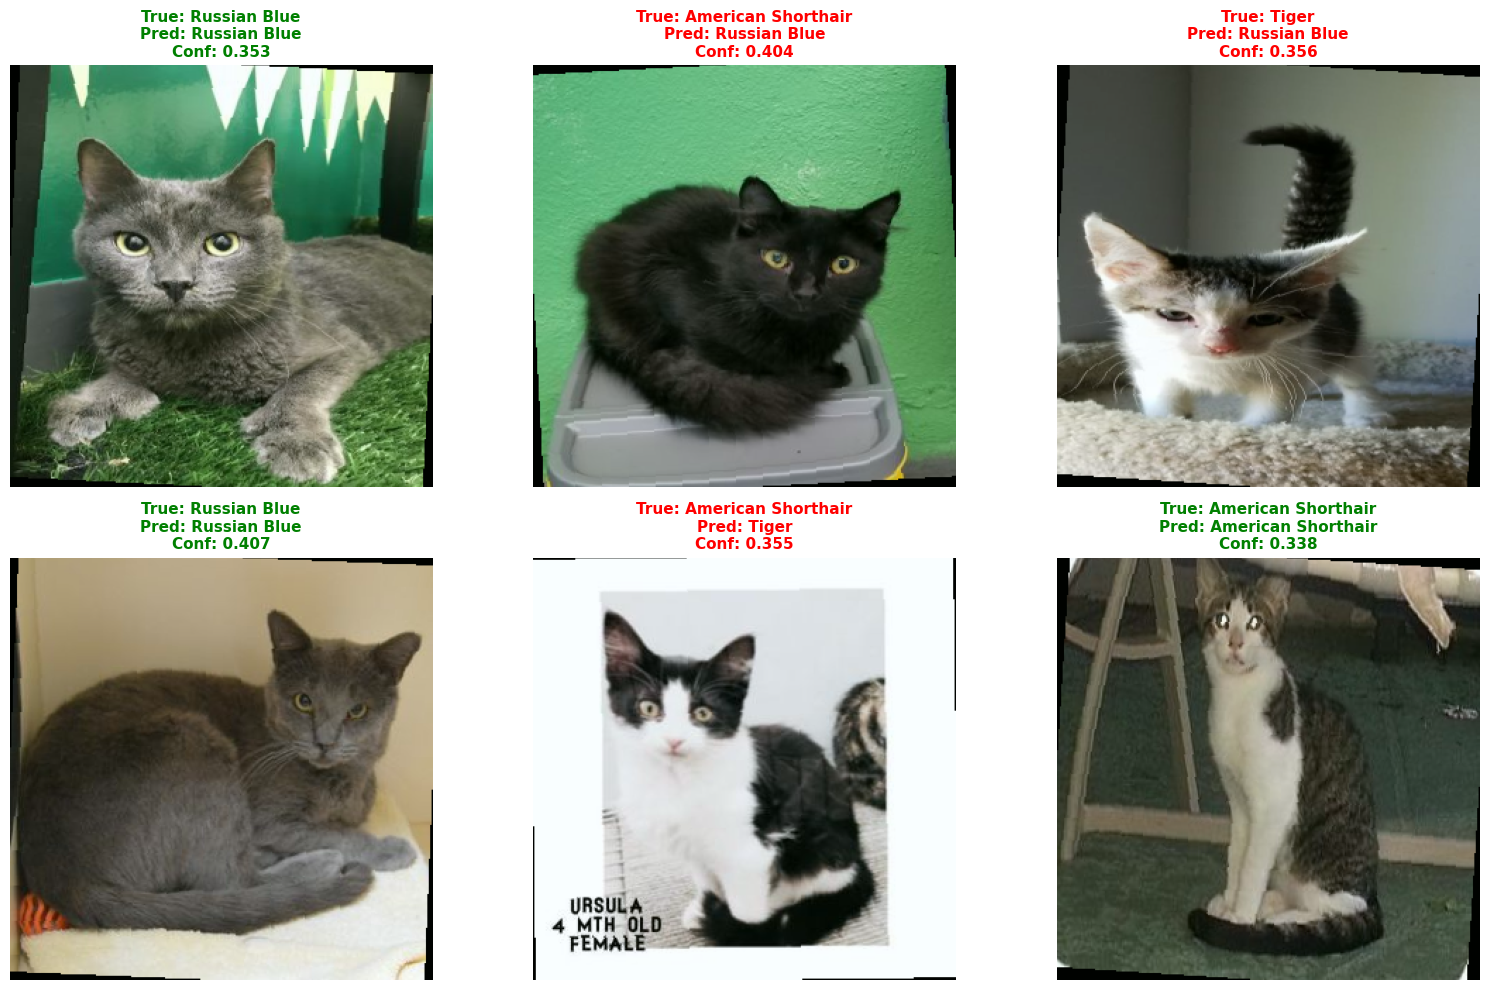

ТЕСТОВЫЙ ДАТАСЕТ


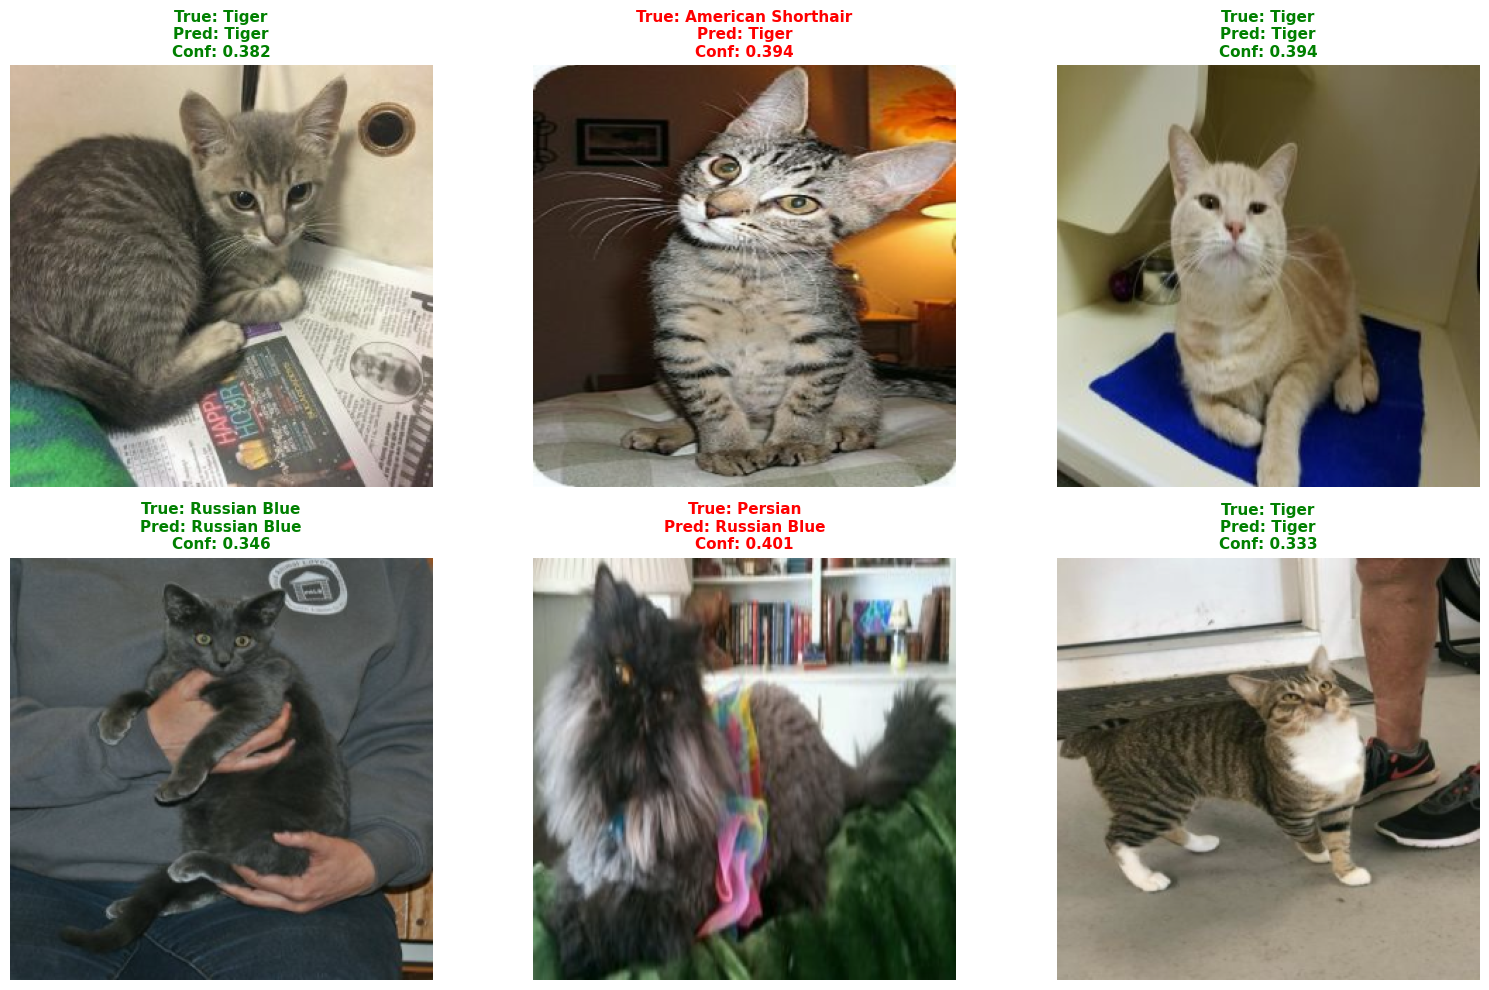

In [39]:
demonstrate_model_predictions()

<p class="task" id="4"></p>

4\. Решите задачу классификации на основе датасета из первого задания, используя сверточные слои. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. Выведите на экран количество параметров модели. Воспользовавшись функцией из предыдущего задания, выведите прогнозы итоговой модели по 6 случайным картинкам.

- [ ] Проверено на семинаре

In [40]:
# 🟩 - всё в порядке / обучающая выборка
# 🟧 - всё плохо
# 🟪 - тестовая выборка

In [41]:
class CatBreedsDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.classes = sorted(set(labels))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.idx_to_class = {idx: cls_name for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label_idx = self.class_to_idx[label]
        return image, label_idx

    def get_class_mapping(self):
        return self.class_to_idx, self.idx_to_class

In [42]:
def create_catbreeds_datasets():
    zip_path = 'cat_breeds_4.zip'
    data_dir = './cat_breeds_data'

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print(f"🟩 Архив распакован в {data_dir}")

    image_paths = []
    labels = []

    print("Поиск изображений...")
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, file))
                label = os.path.basename(root)
                labels.append(label)


    print(f"Найдено {len(image_paths)} изображений")
    print(f"Классы: {sorted(set(labels))}")

    # Распределение по классам
    class_dist = Counter(labels)
    print("\nРаспределение по классам:")
    for breed, count in class_dist.items():
        print(f"   {breed}: {count} изображений")

    print("\nРазделение данных...")
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        image_paths, labels, test_size=0.2, random_state=42, stratify=labels
    )

    print(f"🟩 Обучающая выборка: {len(train_paths)} изображений")
    print(f"🟪 Тестовая выборка: {len(test_paths)} изображений")

    # Преобразования
    train_transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.RandomHorizontalFlip(0.3),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ])

    test_transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
    ])

    train_dataset = CatBreedsDataset(train_paths, train_labels, train_transform)
    test_dataset = CatBreedsDataset(test_paths, test_labels, test_transform)

    class_to_idx, idx_to_class = train_dataset.get_class_mapping()

    return train_dataset, test_dataset, class_to_idx, idx_to_class

In [43]:
result = create_catbreeds_datasets()

🟩 Архив распакован в ./cat_breeds_data
Поиск изображений...
Найдено 4000 изображений
Классы: ['American Shorthair', 'Persian', 'Russian Blue', 'Tiger']

Распределение по классам:
   Russian Blue: 1000 изображений
   Tiger: 1000 изображений
   American Shorthair: 1000 изображений
   Persian: 1000 изображений

Разделение данных...
🟩 Обучающая выборка: 3200 изображений
🟪 Тестовая выборка: 800 изображений


In [44]:
train_dataset, test_dataset, class_to_idx, idx_to_class = result

In [45]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"\n ИНФОРМАЦИЯ О МОДЕЛИ:")
print(f"   Количество классов: {len(class_to_idx)}")
print(f"   Размер обучающей выборки: {len(train_dataset)}")
print(f"   Размер тестовой выборки: {len(test_dataset)}")


 ИНФОРМАЦИЯ О МОДЕЛИ:
   Количество классов: 4
   Размер обучающей выборки: 3200
   Размер тестовой выборки: 800


In [46]:
class SimpleCatCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCatCNN, self).__init__()

        self.features = nn.Sequential(
            # Блок 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            # Блок 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            # Блок 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            # Блок 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [47]:
model = SimpleCatCNN(num_classes=len(class_to_idx))
total_params = model.count_parameters()
print(f"   Количество параметров модели: {total_params:,}")

   Количество параметров модели: 2,490,116


In [48]:
import json
import pandas as pd
from datetime import datetime

def train_model_with_progress(model, train_loader, test_loader, num_epochs=15, model_name="cat_breeds_model"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    train_losses = []
    train_accuracies = []
    test_accuracies = []

    best_test_acc = 0.0
    best_epoch = 0

    results_dir = f"results_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    os.makedirs(results_dir, exist_ok=True)


    for epoch in range(num_epochs):
        # ===== ОБУЧЕНИЕ =====
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        train_pbar = tqdm(train_loader, desc=f'🟩 Эпоха {epoch+1:02d}/{num_epochs} [ОБУЧЕНИЕ]',
                         bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

        for batch_idx, (images, labels) in enumerate(train_pbar):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            current_acc = 100 * correct / total
            avg_loss = running_loss / (batch_idx + 1)
            train_pbar.set_postfix({
                'Loss': f'{avg_loss:.4f}',
                'Acc': f'{current_acc:.2f}%',
                'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
            })

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        model.eval()
        test_correct = 0
        test_total = 0

        test_pbar = tqdm(test_loader, desc=f'🟪 Эпоха {epoch+1:02d}/{num_epochs} [ТЕСТИРОВАНИЕ]',
                        bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

        with torch.no_grad():
            for images, labels in test_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

                current_test_acc = 100 * test_correct / test_total
                test_pbar.set_postfix({
                    'Test Acc': f'{current_test_acc:.2f}%'
                })

        test_acc = 100 * test_correct / test_total
        test_accuracies.append(test_acc)

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': epoch_loss,
                'train_acc': epoch_acc,
                'test_acc': test_acc,
                'class_to_idx': class_to_idx
            }, f'{results_dir}/best_model.pth')

            print(f"Сохранена лучшая модель. Точность: {test_acc:.2f}%")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': epoch_loss,
                'train_acc': epoch_acc,
                'test_acc': test_acc,
            }, f'{results_dir}/model_epoch_{epoch+1}.pth')

        scheduler.step()

        print(f"\n ЭПОХА {epoch+1:02d}/{num_epochs} - РЕЗУЛЬТАТЫ:")
        print(f"   🟧 Потери: {epoch_loss:.4f}")
        print(f"   🟩 Обучающая точность: {epoch_acc:.2f}%")
        print(f"   🟪 Тестовая точность: {test_acc:.2f}%")
        print(f"   🟩 Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

        if epoch > 0:
            if test_acc > test_accuracies[-2]:
                improvement = test_acc - test_accuracies[-2]
                print(f"   🟪 Улучшение тестовой точности: +{improvement:.2f}%")

        print("-" * 50)
    save_training_history(train_losses, train_accuracies, test_accuracies, results_dir, best_epoch, best_test_acc)

    return train_losses, train_accuracies, test_accuracies, results_dir, best_test_acc



def save_training_history(train_losses, train_accuracies, test_accuracies, results_dir, best_epoch, best_test_acc):
    history_df = pd.DataFrame({
        'epoch': range(1, len(train_losses) + 1),
        'train_loss': train_losses,
        'train_accuracy': train_accuracies,
        'test_accuracy': test_accuracies
    })
    history_df.to_csv(f'{results_dir}/training_history.csv', index=False)

    metrics = {
        'best_epoch': best_epoch,
        'best_test_accuracy': best_test_acc,
        'final_train_accuracy': train_accuracies[-1],
        'final_test_accuracy': test_accuracies[-1],
        'final_train_loss': train_losses[-1],
        'total_epochs': len(train_losses),
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    with open(f'{results_dir}/training_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=4)

    print(f"История обучения сохранена в папку: {results_dir}")

def save_final_results(model, train_accuracy, test_accuracy, class_to_idx, results_dir):
    model_info = {
        'model_architecture': str(model),
        'total_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'class_mapping': class_to_idx,
        'num_classes': len(class_to_idx),
        'save_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    with open(f'{results_dir}/model_info.json', 'w') as f:
        json.dump(model_info, f, indent=4, default=str)

    torch.save({
        'model_state_dict': model.state_dict(),
        'class_to_idx': class_to_idx,
        'model_info': model_info
    }, f'{results_dir}/final_model.pth')

    print(f"Финальная модель и информация сохранены в: {results_dir}")



def save_prediction_examples(model, test_dataset, idx_to_class, results_dir, num_samples=12):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    indices = random.sample(range(len(test_dataset)), num_samples)

    predictions = []

    for i, idx in enumerate(indices):
        image, true_label = test_dataset[idx]

        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            predicted_label = predicted.item()
            confidence_score = confidence.item()

        true_class = idx_to_class[true_label]
        pred_class = idx_to_class[predicted_label]
        is_correct = predicted_label == true_label

        predictions.append({
            'image_index': idx,
            'true_class': true_class,
            'predicted_class': pred_class,
            'confidence': confidence_score,
            'is_correct': is_correct
        })

    pred_df = pd.DataFrame(predictions)
    pred_df.to_csv(f'{results_dir}/prediction_examples.csv', index=False)

    print(f"Примеры предсказаний сохранены: {len(predictions)} записей")

    return predictions

In [49]:
train_losses, train_accuracies, test_accuracies = train_model_with_progress(
    model, train_loader, test_loader, num_epochs=100
)

🟩 Эпоха 01/100 [ОБУЧЕНИЕ]: 100%|████████████████████| 200/200 [00:03<00:00, 51.55it/s, Loss=1.3730, Acc=42.88%, LR=0.00
🟪 Эпоха 01/100 [ТЕСТИРОВАНИЕ]: 100%|████████████████████| 50/50 [00:00<00:00, 77.19it/s, Test Acc=52.25%]              


Сохранена лучшая модель. Точность: 52.25%

 ЭПОХА 01/100 - РЕЗУЛЬТАТЫ:
   🟧 Потери: 1.3730
   🟩 Обучающая точность: 42.88%
   🟪 Тестовая точность: 52.25%
   🟩 Learning Rate: 0.001000
--------------------------------------------------


🟩 Эпоха 02/100 [ОБУЧЕНИЕ]: 100%|████████████████████| 200/200 [00:03<00:00, 54.90it/s, Loss=1.1864, Acc=48.41%, LR=0.00
🟪 Эпоха 02/100 [ТЕСТИРОВАНИЕ]: 100%|████████████████████| 50/50 [00:00<00:00, 79.03it/s, Test Acc=48.25%]              



 ЭПОХА 02/100 - РЕЗУЛЬТАТЫ:
   🟧 Потери: 1.1864
   🟩 Обучающая точность: 48.41%
   🟪 Тестовая точность: 48.25%
   🟩 Learning Rate: 0.001000
--------------------------------------------------


🟩 Эпоха 03/100 [ОБУЧЕНИЕ]: 100%|████████████████████| 200/200 [00:03<00:00, 54.43it/s, Loss=1.1734, Acc=50.59%, LR=0.00
🟪 Эпоха 03/100 [ТЕСТИРОВАНИЕ]: 100%|████████████████████| 50/50 [00:00<00:00, 79.40it/s, Test Acc=48.50%]              


...

🟩 Эпоха 99/100 [ОБУЧЕНИЕ]: 100%|████████████████████| 200/200 [00:03<00:00, 52.26it/s, Loss=0.2663, Acc=90.78%, LR=0.00
🟪 Эпоха 99/100 [ТЕСТИРОВАНИЕ]: 100%|████████████████████| 50/50 [00:01<00:00, 43.88it/s, Test Acc=71.25%]              



 ЭПОХА 99/100 - РЕЗУЛЬТАТЫ:
   🟧 Потери: 0.2663
   🟩 Обучающая точность: 90.78%
   🟪 Тестовая точность: 71.25%
   🟩 Learning Rate: 0.000002
--------------------------------------------------


🟩 Эпоха 100/100 [ОБУЧЕНИЕ]: 100%|████████████████████| 200/200 [00:03<00:00, 52.68it/s, Loss=0.2676, Acc=91.19%, LR=0.0
🟪 Эпоха 100/100 [ТЕСТИРОВАНИЕ]: 100%|████████████████████| 50/50 [00:00<00:00, 73.89it/s, Test Acc=71.12%]             



 ЭПОХА 100/100 - РЕЗУЛЬТАТЫ:
   🟧 Потери: 0.2676
   🟩 Обучающая точность: 91.19%
   🟪 Тестовая точность: 71.12%
   🟩 Learning Rate: 0.000001
--------------------------------------------------
История обучения сохранена в папку: results_20260830_095355


ValueError: too many values to unpack (expected 3)

In [50]:
def plot_training_history(train_losses, train_accuracies, test_accuracies):
    plt.style.use('seaborn-v0_8')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # График потерь
    ax1.plot(train_losses, 'b-', linewidth=2.5, marker='o', markersize=4, label='Training Loss')
    ax1.set_title('Динамика функции потерь', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xlabel('Эпоха', fontsize=12)
    ax1.set_ylabel('Потери', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)

    # График точности
    ax2.plot(train_accuracies, 'g-', linewidth=2.5, marker='s', markersize=4, label='Train Accuracy')
    ax2.plot(test_accuracies, 'r-', linewidth=2.5, marker='^', markersize=4, label='Test Accuracy')
    ax2.set_title('Динамика точности', fontsize=14, fontweight='bold', pad=20)
    ax2.set_xlabel('Эпоха', fontsize=12)
    ax2.set_ylabel('Точность (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)

    ax1.annotate(f'Final: {train_losses[-1]:.4f}',
                xy=(len(train_losses)-1, train_losses[-1]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))

    ax2.annotate(f'Train: {train_accuracies[-1]:.1f}%',
                xy=(len(train_accuracies)-1, train_accuracies[-1]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

    ax2.annotate(f'Test: {test_accuracies[-1]:.1f}%',
                xy=(len(test_accuracies)-1, test_accuracies[-1]),
                xytext=(10, -25), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))

    plt.tight_layout()
    plt.show()



def evaluate_model(model, train_loader, test_loader, idx_to_class):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    print("\n" + "=" * 60)
    print("ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ")
    print("=" * 60)

    # Точность на обучающей выборке
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(train_loader, desc='🟩 Оценка обучающей выборки',
                     bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

    with torch.no_grad():
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            current_acc = 100 * train_correct / train_total
            train_pbar.set_postfix({'Accuracy': f'{current_acc:.2f}%'})

    train_accuracy = 100 * train_correct / train_total

    # Точность на тестовой выборке
    test_correct = 0
    test_total = 0

    test_pbar = tqdm(test_loader, desc='🟪 Оценка тестовой выборки',
                    bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

    with torch.no_grad():
        for images, labels in test_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

            current_acc = 100 * test_correct / test_total
            test_pbar.set_postfix({'Accuracy': f'{current_acc:.2f}%'})

    test_accuracy = 100 * test_correct / test_total

    print("\n ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
    print("━" * 40)
    print(f"🟩 Точность на обучающей выборке: {train_accuracy:.2f}%")
    print(f"🟪 Точность на тестовой выборке:  {test_accuracy:.2f}%")


    return train_accuracy, test_accuracy

def visualize_predictions(model, dataset, idx_to_class, num_samples=6):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.ravel()

    print(f"\nВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ НА {num_samples} ИЗОБРАЖЕНИЯХ")
    print("━" * 50)

    for i, idx in enumerate(indices):
        image, true_label = dataset[idx]

        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            predicted_label = predicted.item()
            confidence_score = confidence.item()

        image_np = image.numpy().transpose(1, 2, 0)
        image_np = np.clip(image_np, 0, 1)

        is_correct = predicted_label == true_label
        color = 'green' if is_correct else 'red'
        result_text = "🟩 ПРАВИЛЬНО" if is_correct else "🟧 ОШИБКА"

        axes[i].imshow(image_np)
        true_class = idx_to_class[true_label]
        pred_class = idx_to_class[predicted_label]

        title = f'{result_text}\nИстина: {true_class}\nПредсказание: {pred_class}\nУверенность: {confidence_score:.2f}'
        axes[i].set_title(title, color=color, fontsize=11, pad=10)
        axes[i].axis('off')
        print(f"Изображение {i+1}: {true_class} → {pred_class} [{confidence_score:.2f}] {result_text}")

    plt.tight_layout()
    plt.show()

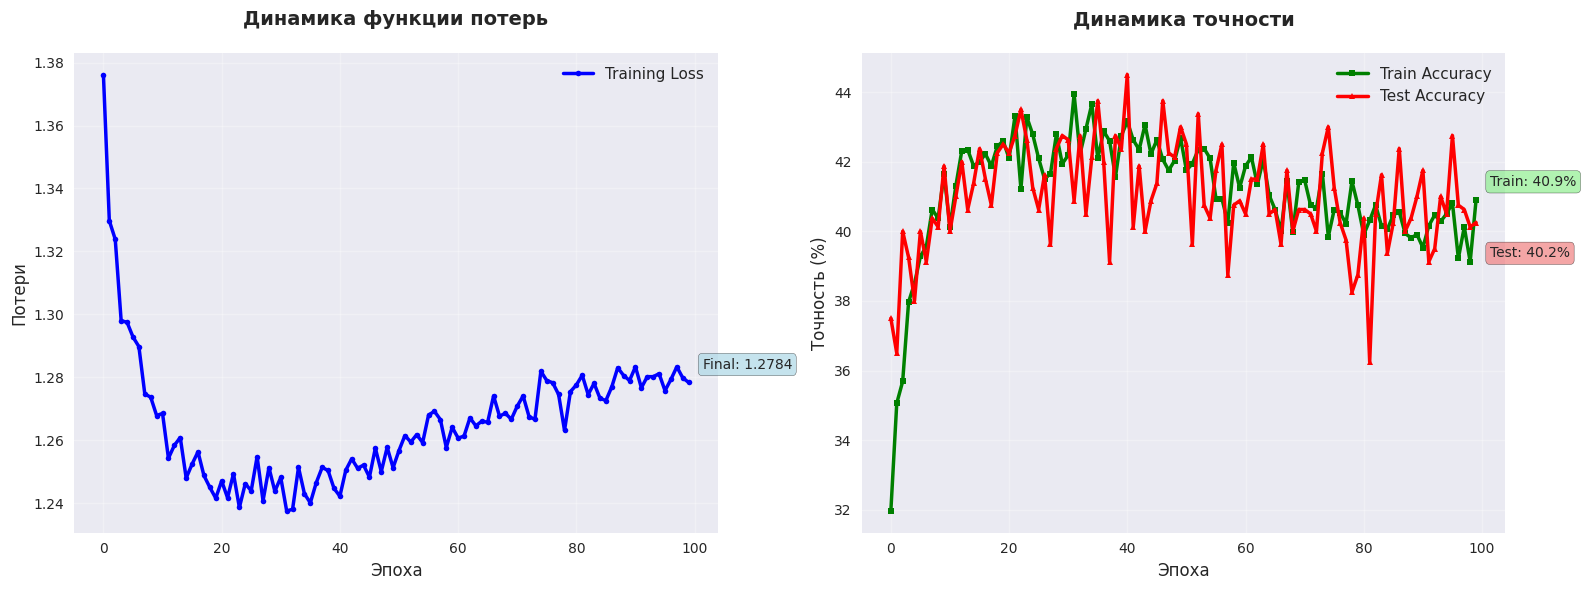

In [51]:
plot_training_history(train_losses, train_accuracies, test_accuracies)

<p class="task" id="5"></p>

5\. Проанализируйте обученную в предыдущей задаче модель, исследовав обученные ядра сверточных слоев. Выберите одно изображение из тестового набора данных и пропустите через первый сверточный слой модели. Визуализируйте полученные карты признаков.

- [ ] Проверено на семинаре

Устройство: cuda
Загрузка данных из cat_breeds_4.zip...
Создание датасета из zip архива...
Найдено 4000 изображений
Классы: ['American Shorthair', 'Persian', 'Russian Blue', 'Tiger']
   Датасет создан!
   Классы: ['American Shorthair', 'Persian', 'Russian Blue', 'Tiger']
   Обучающих изображений: 3200
   Тестовых изображений: 800
Модель создана! Количество классов: 4
БЫСТРЫЙ ВЫВОД КАРТ ПРИЗНАКОВ

Изображение 1: класс 'Persian'
   Используем слой: Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   Размер карт признаков: torch.Size([1, 32, 300, 300])


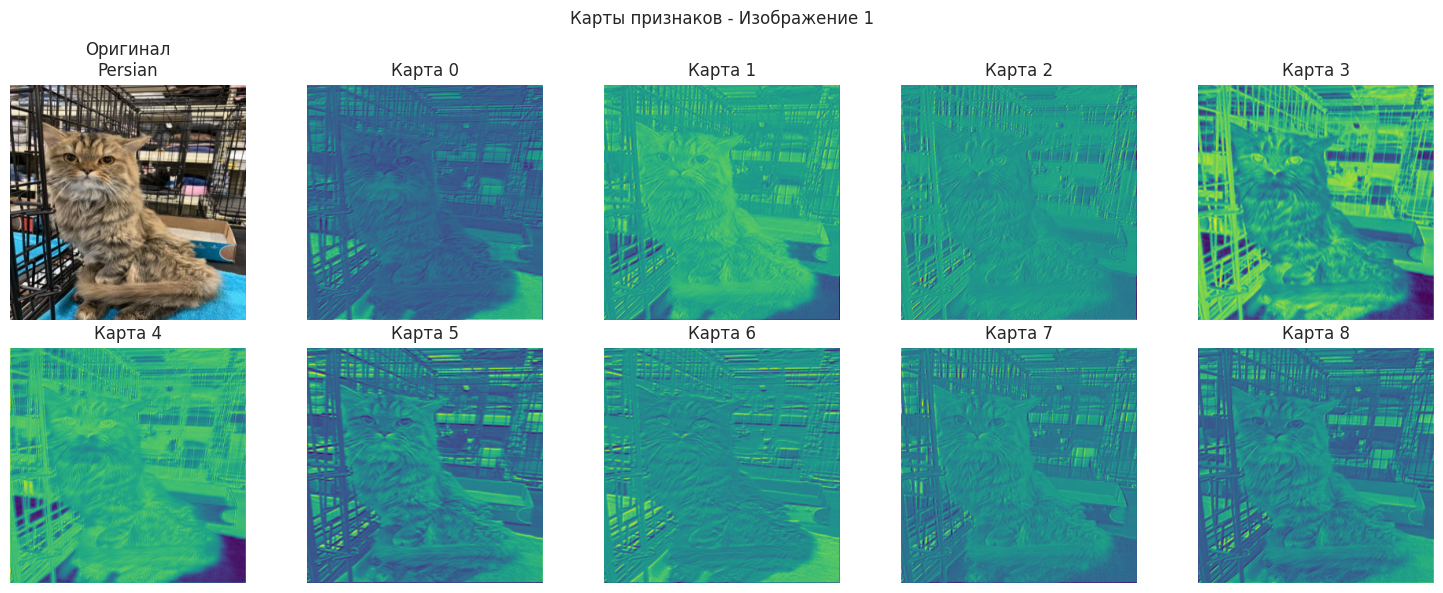

Показано 9 карт признаков

Изображение 2: класс 'Persian'
   Используем слой: Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   Размер карт признаков: torch.Size([1, 32, 300, 300])


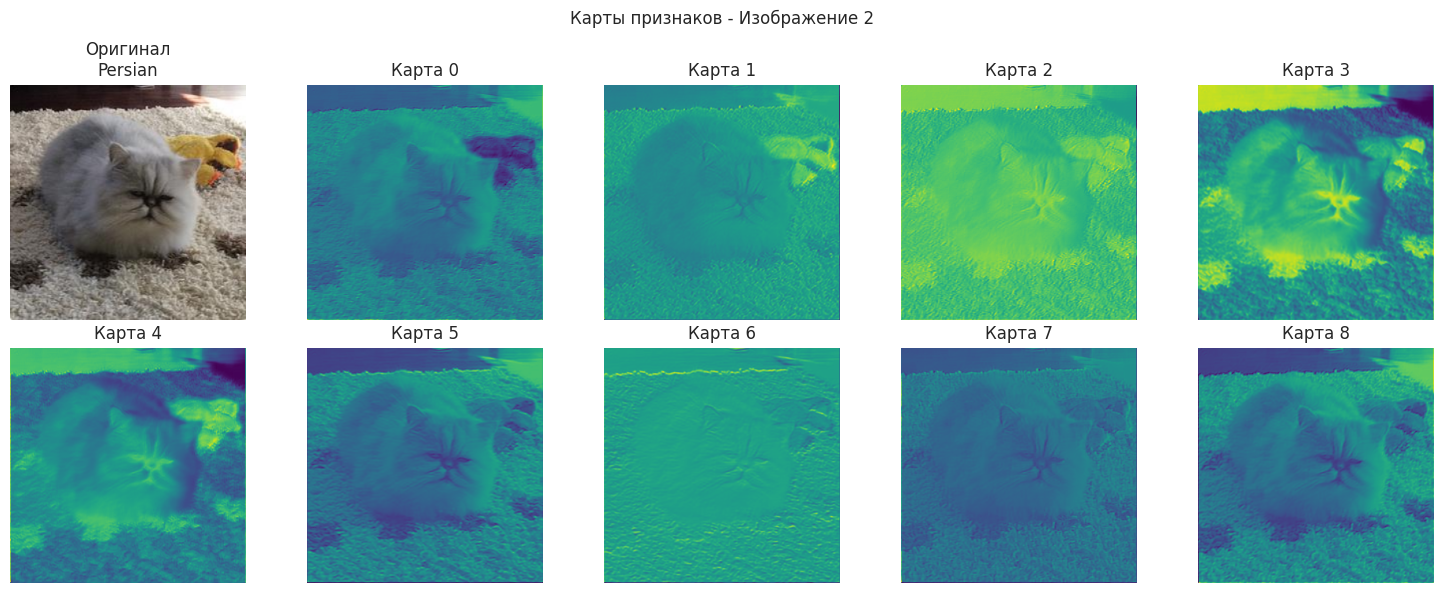

Показано 9 карт признаков

АНАЛИЗ СВЕРТОЧНЫХ ЯДЕР
Найдено сверточных слоев: 3
   Первый слой 'features.0':
   Форма: (32, 3, 3, 3)
   Min: -0.1916, Max: 0.1919


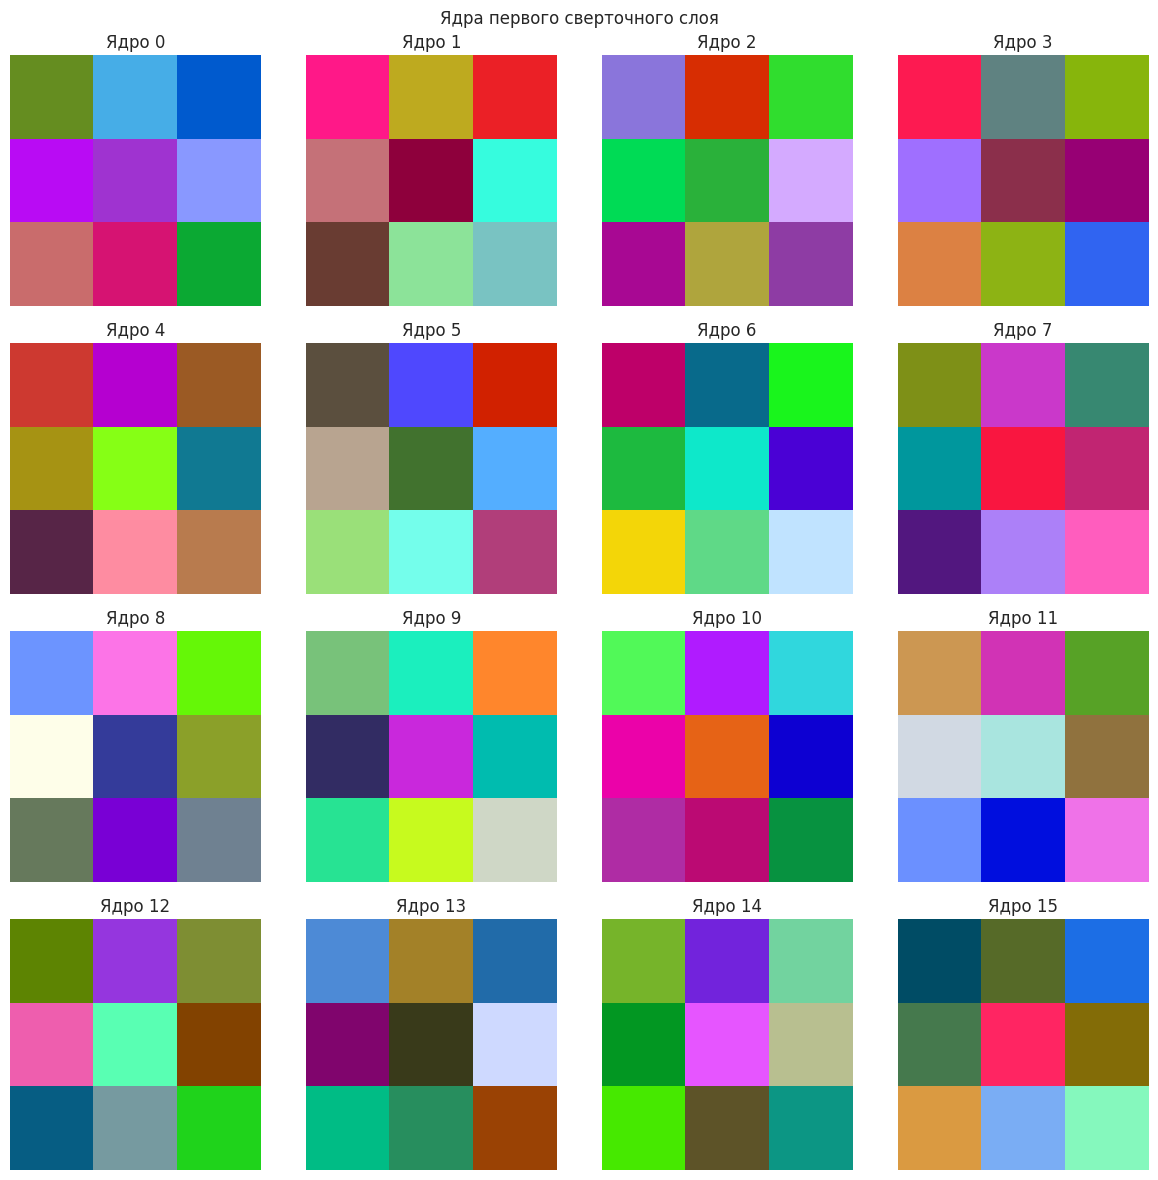


ТЕСТИРОВАНИЕ МОДЕЛИ
Точность на 32 изображениях: 34.38%

 АНАЛИЗ ЗАВЕРШЕН!


In [52]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from PIL import Image
import random
import os
import zipfile
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class CatBreedsDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.classes = sorted(set(labels))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.idx_to_class = {idx: cls_name for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label_idx = self.class_to_idx[label]
        return image, label_idx

class SimpleCatCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCatCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

def create_dataset_from_zip(zip_path='cat_breeds_4.zip'):
    """Создает датасет из zip архива"""
    print("Создание датасета из zip архива...")

    extract_to = './cat_breeds_data'
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"Архив распакован в {extract_to}")

    image_paths = []
    labels = []

    for root, dirs, files in os.walk(extract_to):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, file))
                label = os.path.basename(root)
                labels.append(label)

    if len(image_paths) == 0:
        print("Не найдено изображений в архиве!")
        return None, None, None, None

    print(f"Найдено {len(image_paths)} изображений")
    print(f"Классы: {sorted(set(labels))}")

    train_paths, test_paths, train_labels, test_labels = train_test_split(
        image_paths, labels, test_size=0.2, random_state=42, stratify=labels
    )

    transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
    ])

    train_dataset = CatBreedsDataset(train_paths, train_labels, transform)
    test_dataset = CatBreedsDataset(test_paths, test_labels, transform)

    return train_dataset, test_dataset, train_dataset.class_to_idx, train_dataset.idx_to_class


def show_feature_maps_simple(model, dataset, device, num_images=2):
    """Простая функция для показа карт признаков"""
    print("БЫСТРЫЙ ВЫВОД КАРТ ПРИЗНАКОВ")
    print("=" * 50)

    for i in range(num_images):
        idx = random.randint(0, len(dataset)-1)
        image, label = dataset[idx]
        class_name = dataset.idx_to_class[label]

        print(f"\nИзображение {i+1}: класс '{class_name}'")

        features_container = [None]  

        conv_layers = []
        for module in model.modules():
            if isinstance(module, nn.Conv2d):
                conv_layers.append(module)

        if not conv_layers:
            print("В модели нет сверточных слоев!")
            return

        first_conv = conv_layers[0]
        print(f"   Используем слой: {first_conv}")

        def hook_function(module, input, output):
            features_container[0] = output.detach()
        handle = first_conv.register_forward_hook(hook_function)
        model.eval()
        with torch.no_grad():
            _ = model(image.unsqueeze(0).to(device))
        handle.remove()
        if features_container[0] is not None:
            features = features_container[0]
            print(f"   Размер карт признаков: {features.shape}")

            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            axes[0,0].imshow(image.permute(1,2,0))
            axes[0,0].set_title(f'Оригинал\n{class_name}')
            axes[0,0].axis('off')
            for j in range(4):
                if j < features.shape[1]:
                    feature_map = features[0, j].cpu()
                    axes[0,j+1].imshow(feature_map, cmap='viridis')
                    axes[0,j+1].set_title(f'Карта {j}')
                    axes[0,j+1].axis('off')

            for j in range(5):
                if j+4 < features.shape[1]:
                    feature_map = features[0, j+4].cpu()
                    axes[1,j].imshow(feature_map, cmap='viridis')
                    axes[1,j].set_title(f'Карта {j+4}')
                    axes[1,j].axis('off')

            plt.suptitle(f'Карты признаков - Изображение {i+1}')
            plt.tight_layout()
            plt.show()

            print(f"Показано {min(9, features.shape[1])} карт признаков")
        else:
            print("Не удалось извлечь карты признаков")



def analyze_convolutional_kernels_simple(model):
    """Упрощенный анализ сверточных ядер"""
    print("\nАНАЛИЗ СВЕРТОЧНЫХ ЯДЕР")
    print("=" * 40)

    conv_layers = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            conv_layers.append((name, module))

    print(f"Найдено сверточных слоев: {len(conv_layers)}")

    if conv_layers:
        name, layer = conv_layers[0]
        kernels = layer.weight.data.cpu().numpy()
        print(f"   Первый слой '{name}':")
        print(f"   Форма: {kernels.shape}")
        print(f"   Min: {kernels.min():.4f}, Max: {kernels.max():.4f}")

        if kernels.shape[0] >= 16:
            fig, axes = plt.subplots(4, 4, figsize=(12, 12))
            for idx in range(16):
                ax = axes[idx // 4, idx % 4]
                kernel = kernels[idx]
                kernel_vis = (kernel - kernel.min()) / (kernel.max() - kernel.min())
                ax.imshow(kernel_vis.transpose(1, 2, 0))
                ax.set_title(f'Ядро {idx}')
                ax.axis('off')

            plt.suptitle('Ядра первого сверточного слоя')
            plt.tight_layout()
            plt.show()

    return conv_layers


def analyze_model_performance_simple(model, test_loader, device, class_to_idx):
    """Упрощенный анализ производительности"""
    print("\nТЕСТИРОВАНИЕ МОДЕЛИ")
    print("=" * 40)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if total >= 32:
                break

    accuracy = 100 * correct / total if total > 0 else 0
    print(f"Точность на {total} изображениях: {accuracy:.2f}%")

    return accuracy


def main_analysis():
    """Основная функция анализа"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")

    print("Загрузка данных из cat_breeds_4.zip...")
    result = create_dataset_from_zip('cat_breeds_4.zip')

    if result[0] is None:
        print("Не удалось создать датасет!")
        return

    train_dataset, test_dataset, class_to_idx, idx_to_class = result

    print(f"   Датасет создан!")
    print(f"   Классы: {list(class_to_idx.keys())}")
    print(f"   Обучающих изображений: {len(train_dataset)}")
    print(f"   Тестовых изображений: {len(test_dataset)}")

    num_classes = len(class_to_idx)
    model = SimpleCatCNN(num_classes)
    model.to(device)

    print(f"Модель создана! Количество классов: {num_classes}")

    show_feature_maps_simple(model, test_dataset, device, num_images=2)
    analyze_convolutional_kernels_simple(model)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
    analyze_model_performance_simple(model, test_loader, device, class_to_idx)
    print("\n АНАЛИЗ ЗАВЕРШЕН!")

if __name__ == "__main__":
    main_analysis()

## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ